In [28]:
import jax
import jax.numpy as jnp
import diffrax as dfx
import equinox as eqx

import matplotlib.pyplot as plt

from models import HamiltonianNN, NeuralODE
from vector_fields import vector_field_double_mass_spring, vector_field_hnn_potenergy, vector_field_hnn_totenergy, vector_field_node
from utilities import Params, integrate_vector_field, split_train_val, make_minibatches, to_canonical

In [29]:
key = jax.random.PRNGKey(0)

In [30]:
def sample_ic_batch(key, N):
    k1, k2, k3, k4 = jax.random.split(key, 4)
    x0 = jax.random.uniform(k1, (N,), minval=0.2, maxval=0.8)
    x1 = jax.random.uniform(k3, (N,), minval=0.9, maxval=1.4)
    v0 = jax.random.uniform(k2, (N,), minval=-0.7, maxval=0.7)
    v1 = jax.random.uniform(k4, (N,), minval=-0.7, maxval=0.7)
    return jnp.stack([x0, x1, v0, v1], axis=-1)

ys_all: (2000, 101, 4)


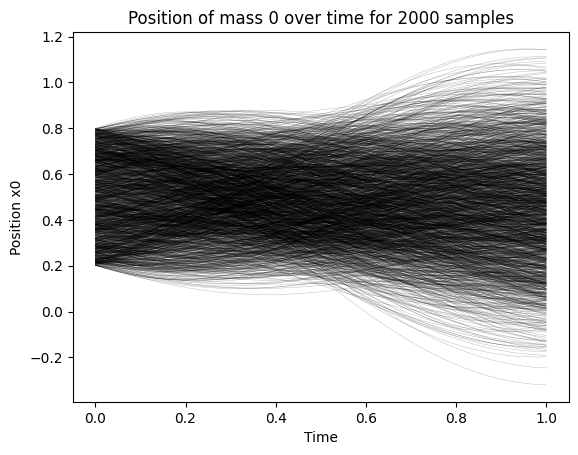

In [31]:
system_params = Params(m0=1.0, m1=1.2, k0=3.0, k1=5.0, L0=0.4, L1=0.6)
ts = jnp.linspace(0.0, 1.0, 101)

y0s = sample_ic_batch(key, 2000)

solve_batch = integrate_vector_field(ts=ts, term=vector_field_double_mass_spring)
ys_all = solve_batch(model=None, params=system_params, y0s=y0s)   # (N, T, 4)
print("ys_all:", ys_all.shape)


plt.figure()
for i in range(ys_all.shape[0]):
    plt.plot(ts, ys_all[i, :, 0], alpha=0.3, color='black', lw=0.3)  # x0
plt.title('Position of mass 0 over time for 2000 samples')
plt.xlabel('Time')
plt.ylabel('Position x0')
plt.show()

### Initialize neural networks

In [32]:
key, subkey = jax.random.split(key)
hnn_potenergy = HamiltonianNN(key=subkey, input_dim=2, hidden_dim=64)
hnn_potenergy_params, hnn_potenergy_static = eqx.partition(hnn_potenergy, eqx.is_array)

key, subkey = jax.random.split(key)
hnn_totenergy = HamiltonianNN(key=subkey, input_dim=4, hidden_dim=64)
hnn_totenergy_params, hnn_totenergy_static = eqx.partition(hnn_totenergy, eqx.is_array)

key, subkey = jax.random.split(key)
node = NeuralODE(key=subkey, input_dim=4, hidden_dim=64, output_dim=2)
node_params, node_static = eqx.partition(node, eqx.is_array)

In [33]:
ys_can = to_canonical(ys_all, system_params.m0, system_params.m1)

key, subkey = jax.random.split(key)
train_all, val_all = split_train_val(subkey, ys_can, 0.85)

### Train HNN model 1 (learning potential energy)

In [34]:
from train import train_partially_observed

In [35]:
# run_hnn_potenergy = integrate_vector_field(ts, term=vector_field_hnn_potenergy)
# hnn_potenergy_params, hnn_potenergy_static = train_partially_observed(
#     batch_size=64, 
#     epochs=300, 
#     key=subkey, 
#     run_hnn=run_hnn_potenergy, 
#     system_params=system_params, 
#     model_params=hnn_potenergy_params, 
#     model_static=hnn_potenergy_static, 
#     train_all=train_all, 
#     val_all=val_all, 
#     learning_rate=1e-3
# )

In [36]:
# run_hnn_totenergy = integrate_vector_field(ts, term=vector_field_hnn_totenergy)
# hnn_totenergy_params, hnn_totenergy_static = train_partially_observed(
#     batch_size=64, 
#     epochs=300, 
#     key=subkey, 
#     run_hnn=run_hnn_totenergy, 
#     system_params=system_params, 
#     model_params=hnn_totenergy_params, 
#     model_static=hnn_totenergy_static, 
#     train_all=train_all, 
#     val_all=val_all, 
#     learning_rate=1e-3
# )

In [37]:
# run_node = integrate_vector_field(ts, term=vector_field_node)
# node_params, node_static = train_partially_observed(
#     batch_size=64,
#     epochs=300, 
#     key=subkey, 
#     run_hnn=run_node, 
#     system_params=system_params, 
#     model_params=node_params, 
#     model_static=node_static, 
#     train_all=train_all, 
#     val_all=val_all, 
#     learning_rate=1e-3
# )

### Load models

In [38]:
from utilities import load_model

In [ ]:
model_like_hnn_pot = HamiltonianNN(input_dim=2, key=jax.random.PRNGKey(0))
system_params_like = Params(m0=1.0, m1=1.2, k0=3.0, k1=5.0, L0=0.4, L1=0.6)

model_name_hnn_pot = "hnn_potenergy_double_mass_spring_model"
hnn_pot_checkpoint_dir = "checkpoints/old"
aux_like = {"system_params": system_params_like}

hnn_model_pot, aux_loaded_pot = load_model(
    model_name = model_name_hnn_pot,
    ckpt_dir = hnn_pot_checkpoint_dir,
    model_like = model_like_hnn_pot,
    aux_like = aux_like,
)

In [40]:
aux_loaded_pot

Params(m0=1.0, m1=1.2, k0=3.0, k1=5.0, L0=0.4, L1=0.6)

In [41]:
model_like_hnn_tot = HamiltonianNN(input_dim=4, key=jax.random.PRNGKey(0))
system_params_like = Params(m0=1.0, m1=1.2, k0=3.0, k1=5.0, L0=0.4, L1=0.6)

model_name_hnn_tot = "hnn_totenergy_double_mass_spring"
hnn_tot_checkpoint_dir = "checkpoints"
aux_like = {"system_params": system_params_like}

hnn_model_tot, aux_loaded_tot = load_model(
    model_name = model_name_hnn_tot,
    ckpt_dir = hnn_tot_checkpoint_dir,
    model_like = model_like_hnn_tot,
    aux_like = aux_like,
)

FileNotFoundError: checkpoints/hnn_totenergy_double_mass_spring_model.eqx

In [ ]:
model_like_node = NeuralODE(input_dim=4, output_dim=2, key=jax.random.PRNGKey(0))
system_params_like = Params(m0=1.0, m1=1.2, k0=3.0, k1=5.0, L0=0.4, L1=0.6)

model_name_node = "node_double_mass_spring"
node_checkpoint_dir = "checkpoints"
aux_like = {"system_params": system_params_like}

node_model, aux_loaded_node = load_model(
    model_name = model_name_node,
    ckpt_dir = node_checkpoint_dir,
    model_like = model_like_node,
    aux_like = aux_like,
)

In [ ]:
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Palatino'
plt.rcParams['font.style'] = 'normal'

sintef_blue = '#003C65'
sintef_cyan = '#22A7E5'
sintef_green = '#A4C21F'
sintef_yellow = '#F7E918'
sintef_magenta = '#EC008C'

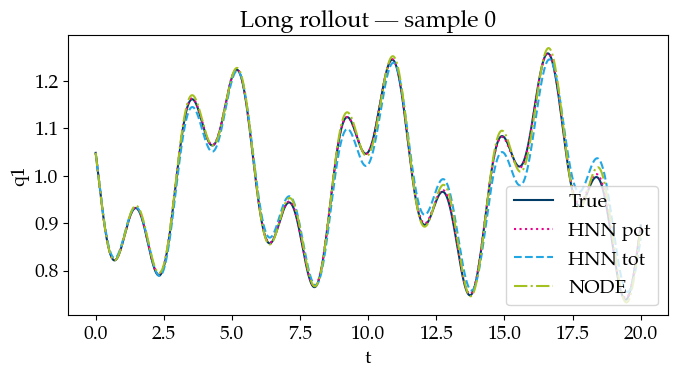

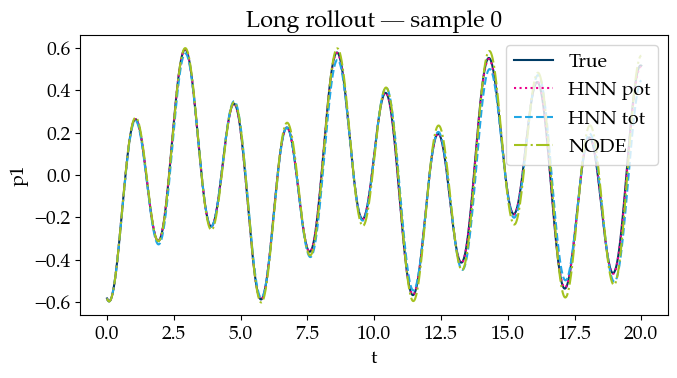

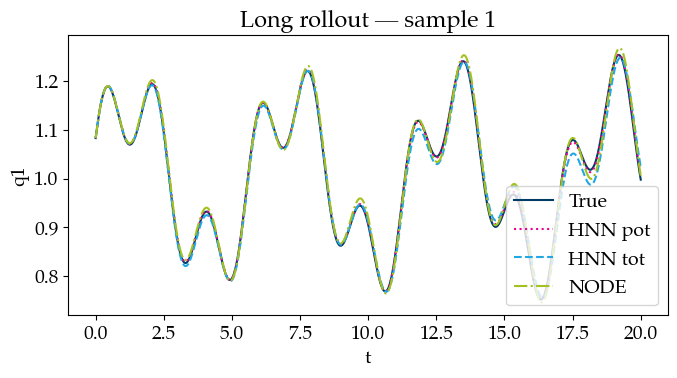

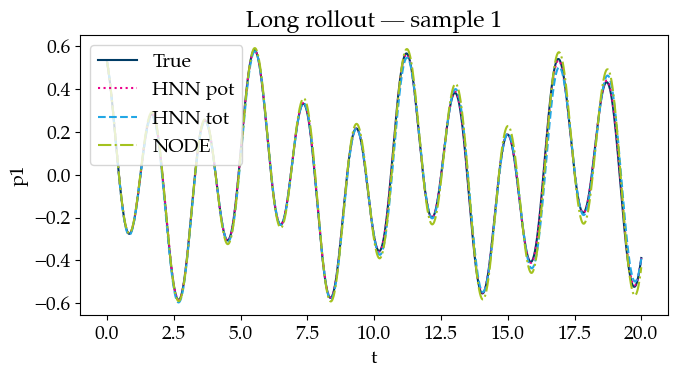

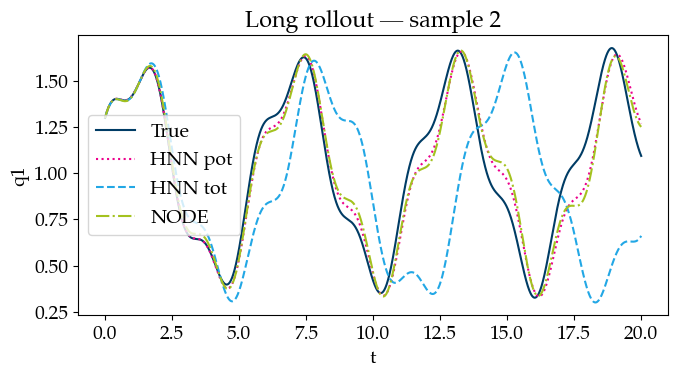

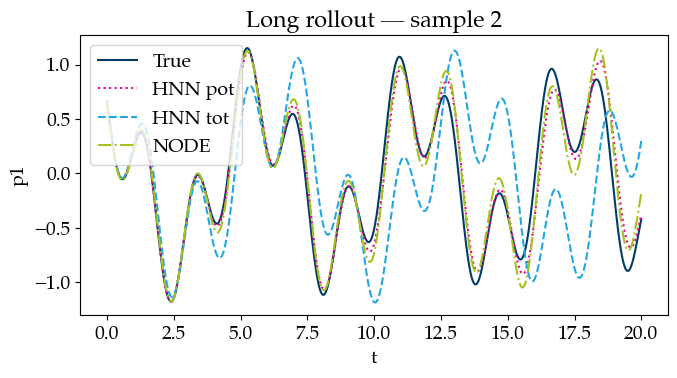

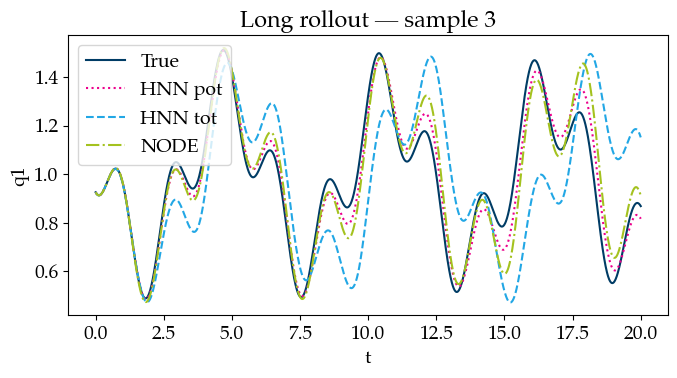

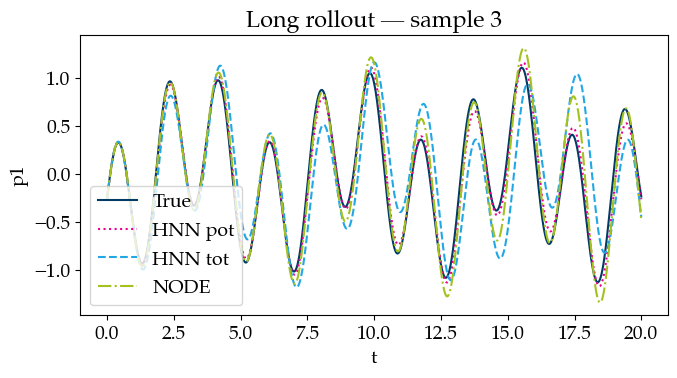

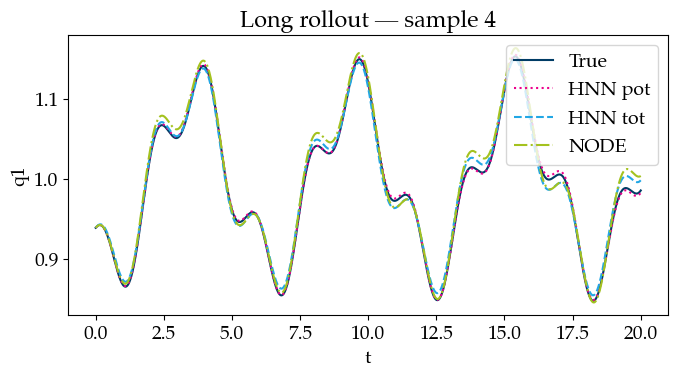

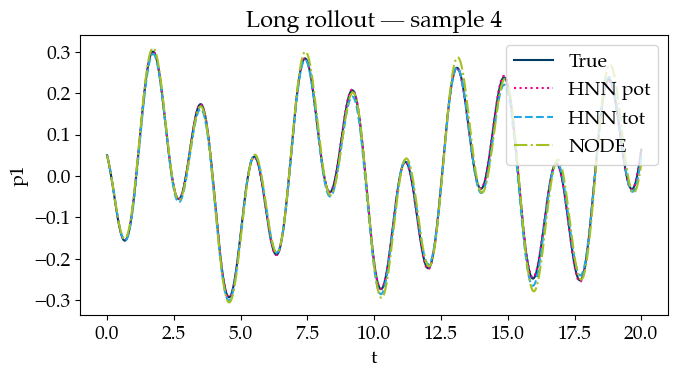

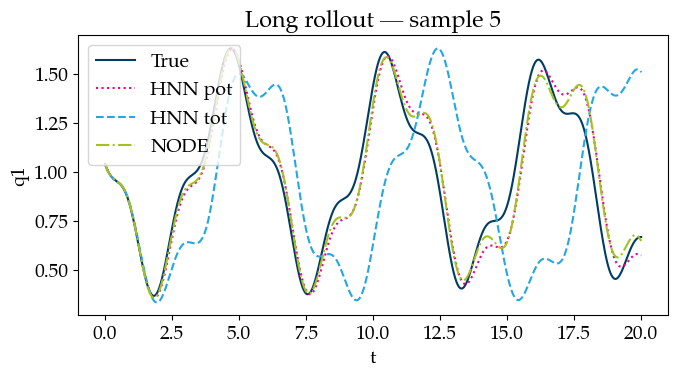

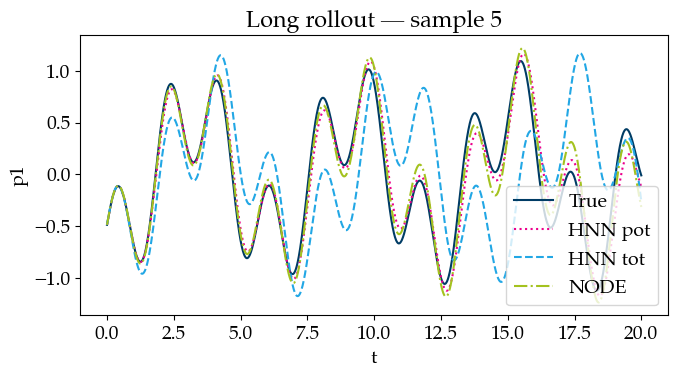

In [ ]:
# ----- make a long grid (same dt) -----
def make_long_ts(ts, factor=10):
    ts = jnp.asarray(ts)
    t0 = float(ts[0]); dt = float(ts[1]-ts[0]); T = float(ts[-1]-ts[0])
    t1 = t0 + factor*T
    n = int(round((t1 - t0)/dt)) + 1
    return jnp.linspace(t0, t1, n)

ts_long = make_long_ts(ts, factor=20)   # e.g., 20x longer


# HNN long integrator
def make_hnn_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_hnn_potenergy)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, params, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

def make_hnn_long_2(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_hnn_totenergy)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, masses, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, masses),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

# # NODE long integrator
def make_node_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_node)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, params, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

def make_truth_long(ts_long, params):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_double_mass_spring)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(y0s_full):
        def to_vel_state(y0_can):
            x0, x1, p0, p1 = y0_can
            return jnp.array([x0, x1, p0/params.m0, p1/params.m1], dtype=jnp.float32)
        def solve_one(y0_can):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=to_vel_state(y0_can), args=(None, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            ys = sol.ys
            x0, x1, v0, v1 = ys.T
            p0, p1 = params.m0*v0, params.m1*v1
            return jnp.stack([x0, x1, p0, p1], axis=-1)
        return jax.vmap(solve_one)(y0s_full)
    return run

run_hnn_long   = make_hnn_long(ts_long)
run_hnn_long_2 = make_hnn_long_2(ts_long)
run_node_long  = make_node_long(ts_long)
run_true_long  = make_truth_long(ts_long, system_params)

B_show  = 6
y0_full = val_all[:B_show, 0]                # (B,4)

hnn_model_final   = hnn_model_pot #eqx.combine(hnn_potenergy_params, hnn_potenergy_static)
hnn_model_final_2 = hnn_model_tot #eqx.combine(hnn_totenergy_params, hnn_totenergy_static)
node_model_final  = node_model #eqx.combine(node_params, node_static)

pred_hnn_long   = run_hnn_long(hnn_model_final, system_params, y0s_full=y0_full)   
pred_hnn_long_2 = run_hnn_long_2(hnn_model_final_2, system_params, y0s_full=y0_full)   
pred_node_long  = run_node_long(node_model_final, system_params, y0s_full=y0_full)
true_long       = run_true_long(y0_full)  

for i in range(B_show):
    plt.figure(figsize=(7,4))
    plt.plot(ts_long, true_long[i,:,1],  label="True", color=sintef_blue)
    plt.plot(ts_long, pred_hnn_long[i,:,1],  ":", label="HNN pot", color=sintef_magenta)
    plt.plot(ts_long, pred_hnn_long_2[i,:,1], "--", label="HNN tot", color=sintef_cyan)
    plt.plot(ts_long, pred_node_long[i,:,1],  "-.", label="NODE", color=sintef_green)
    plt.xlabel("t"); plt.ylabel("q1"); plt.title(f"Long rollout — sample {i}")
    plt.legend(); plt.tight_layout()
    #plt.savefig(f"results/double_mass_spring_q1_sample_{i}.png")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(ts_long, true_long[i,:,3],  label="True", color=sintef_blue)
    plt.plot(ts_long, pred_hnn_long[i,:,3],  ":", label="HNN pot", color=sintef_magenta)
    plt.plot(ts_long, pred_hnn_long_2[i,:,3], "--", label="HNN tot", color=sintef_cyan)
    plt.plot(ts_long, pred_node_long[i,:,3],  "-.", label="NODE", color=sintef_green)
    plt.xlabel("t"); plt.ylabel("p1"); plt.title(f"Long rollout — sample {i}")
    plt.legend(); plt.tight_layout()
    #plt.savefig(f"results/double_mass_spring_p1_sample_{i}.png")
    plt.show()

In [ ]:
# from utilities import save_model, load_model

# save_model("hnn_totenergy_double_mass_spring.eqx", "checkpoints", hnn_model_final_2, aux={"system_params": system_params})
# save_model("hnn_potenergy_double_mass_spring.eqx", "checkpoints", hnn_model_final, aux={"system_params": system_params})
# save_model("node_double_mass_spring.eqx", "checkpoints", node_model_final, aux={"system_params": system_params})

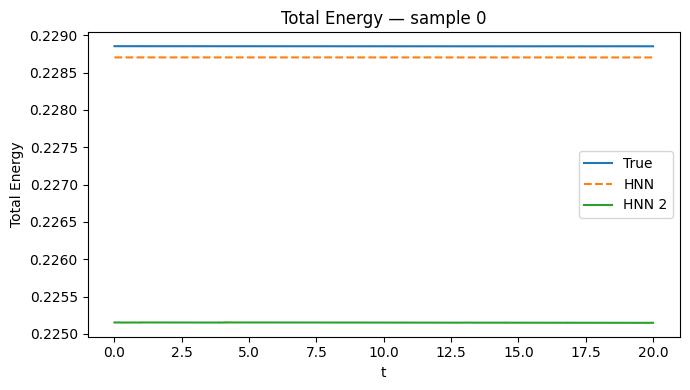

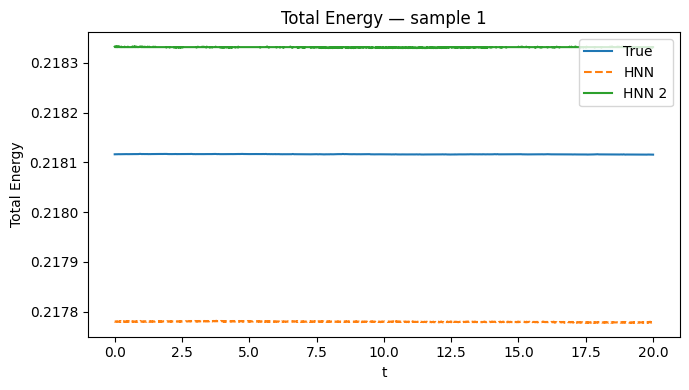

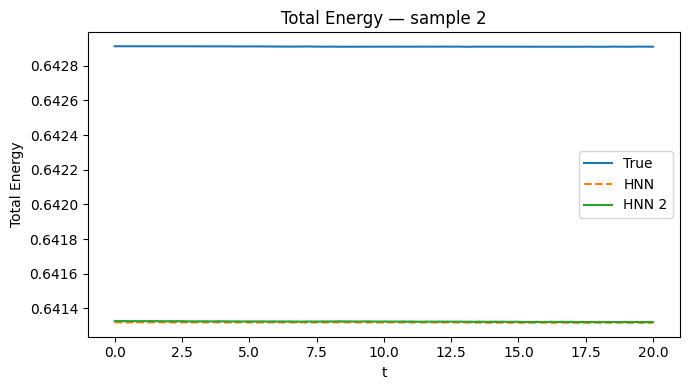

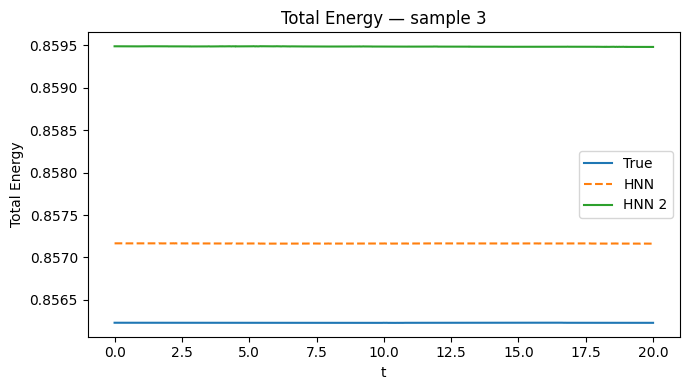

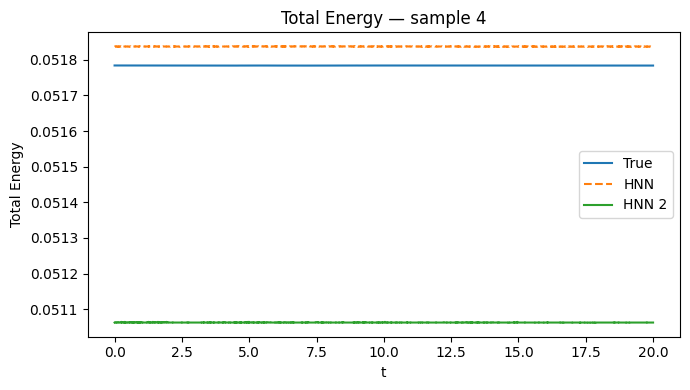

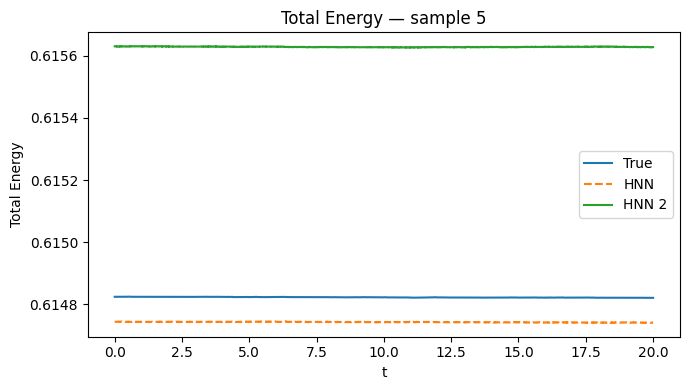

In [ ]:
# Plot total energy, both the true, the HNN model, the HNN 2 model, and the NODE 
def total_energy(y, params: Params):
    x0, x1, p0, p1 = y[...,0], y[...,1], y[...,2], y[...,3]
    ext0 = x0 - params.L0
    ext1 = (x1 - x0) - params.L1
    KE = 0.5*(p0**2/params.m0 + p1**2/params.m1)
    PE = 0.5*(params.k0*ext0**2 + params.k1*ext1**2)
    return KE, PE

def hnn_predicted_energy_2(model, y):
    H = lambda y_: model(y_)                     # scalar, total energy
    return jax.vmap(H)(y)

def hnn_predicted_energy(model, y, params: Params):
    KE, _ = total_energy(y, params)
    PE = lambda y: model(y[:2])                     # scalar, total energy
    return KE + jax.vmap(PE)(y)

for i in range(B_show):
    KE_true, PE_true = total_energy(true_long[i], system_params)
    E_true = KE_true + PE_true
    E_hnn = hnn_predicted_energy(hnn_model_final, pred_hnn_long[i], system_params) - hnn_model_final(jnp.array([system_params.L0, system_params.L0+system_params.L1]))  # shift to zero baseline
    E_hnn_2 = hnn_predicted_energy_2(hnn_model_final_2, pred_hnn_long_2[i]) - hnn_model_final_2(jnp.array([system_params.L0, system_params.L0+system_params.L1, 0., 0.]))  # shift to zero baseline

    plt.figure(figsize=(7,4))
    plt.plot(ts_long, E_true, label="True")
    plt.plot(ts_long, E_hnn, "--", label="HNN")
    plt.plot(ts_long, E_hnn_2, label="HNN 2")
    plt.xlabel("t"); plt.ylabel("Total Energy"); plt.title(f"Total Energy — sample {i}")
    plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors as mcolors
from pathlib import Path


def animate_double_mass_spring_1d_jax(
    y,                         # [N, 4] = [q0, q1, p0, p1]
    y2=None,                   # optional second trajectory with same shape
    save_path="double_mass_spring_1d.gif",
    fps=30,
    dpi=200,                   # higher default resolution
    mass_markersize=20,
    trail_len=None,            # e.g. 50 to show recent path; None for no trails
    title=None,
    margin=0.2,                # padding fraction for x-axis
    frame_step=2,              # subsample frames
):
    """
    Animate a 1D double mass–spring system: wall — spring — mass0 — spring — mass1.

    State per frame: [q0, q1, p0, p1].
    Movement is only along x; we draw masses on a horizontal line y=0.

    If y2 is provided, it is plotted together with y using dashed springs and
    semi-transparent square markers.
    """
    # --- Bring data to NumPy ---
    y_np = np.asarray(jax.device_get(y))
    assert y_np.ndim == 2 and y_np.shape[1] == 4, "y must be [N, 4] = [q0,q1,p0,p1]"
    N, _ = y_np.shape

    y2_np = None
    if y2 is not None:
        y2_np = np.asarray(jax.device_get(y2))
        assert y2_np.shape == y_np.shape, "y2 must have same shape as y"

    # Subsample frames
    idx = np.arange(0, N, frame_step, dtype=int)
    y_np = y_np[idx]
    if y2_np is not None:
        y2_np = y2_np[idx]
    N = y_np.shape[0]

    # Extract positions
    q0 = y_np[:, 0]
    q1 = y_np[:, 1]

    if y2_np is not None:
        q0_2 = y2_np[:, 0]
        q1_2 = y2_np[:, 1]

    # --- Axis limits & wall position ---
    xs_all = [q0, q1]
    if y2_np is not None:
        xs_all.extend([q0_2, q1_2])

    xmin = np.min(xs_all)
    xmax = np.max(xs_all)
    span = xmax - xmin if xmax > xmin else 1.0

    pad = margin * span
    # Put wall a bit to the left of the minimum position
    x_wall = xmin - 0.4 * span

    x_min_plot = x_wall - 0.1 * span
    x_max_plot = xmax + pad

    # --- Helper to make a simple 1D spring (straight–zigzag–straight) ---
    def make_spring_segment(x_start, x_end, n_zig=8, amp=0.03):
        """Return (xs, ys) arrays for a simple zig-zag spring."""
        if np.isclose(x_start, x_end):
            # Degenerate: just a point
            return np.array([x_start]), np.array([0.0])

        # Reserve straight parts at each end (10% each)
        L = x_end - x_start
        left = x_start + 0.1 * L
        right = x_start + 0.9 * L

        # Straight segments
        xs_left = np.array([x_start, left])
        ys_left = np.zeros_like(xs_left)

        xs_right = np.array([right, x_end])
        ys_right = np.zeros_like(xs_right)

        # Zig-zag in the middle
        xs_mid = np.linspace(left, right, n_zig + 1)
        ys_mid = np.zeros_like(xs_mid)
        for i in range(1, n_zig):
            ys_mid[i] = amp * (1 if i % 2 == 0 else -1)

        # Concatenate
        xs = np.concatenate([xs_left, xs_mid, xs_right])
        ys = np.concatenate([ys_left, ys_mid, ys_right])
        return xs, ys

    # --- Figure setup ---
    # Slightly larger figure + higher dpi → nicer video
    fig, ax = plt.subplots(figsize=(8, 3.5), dpi=dpi)
    if title:
        ax.set_title(title)

    ax.set_xlim(x_min_plot, x_max_plot)
    ax.set_ylim(-0.6, 0.6)
    ax.set_yticks([])
    ax.set_xlabel("x")
    ax.axhline(0.0, color="lightgray", lw=0.5, zorder=0)

    # Draw wall (fixed), short and chunky
    ax.plot([x_wall, x_wall], [-0.3, 0.3], color="grey", lw=4,
            solid_capstyle="round", zorder=1)

    mass_colors = ['#1f77b4', '#ff7f0e']

    # --- Primary trajectory artists (outlined, semi-transparent fill) ---
    mass_scatter = []
    for i in range(2):
        edge = mass_colors[i]
        face = mcolors.to_rgba(mass_colors[i], alpha=0.4)
        sc, = ax.plot(
            [], [], "o",
            ms=mass_markersize,
            markeredgecolor=edge,
            markeredgewidth=1.0,
            markerfacecolor=face,
            zorder=5,
        )
        mass_scatter.append(sc)

    spring_wall_to_m0, = ax.plot([], [], "-", color="gray", lw=1, zorder=2)
    spring_m0_to_m1, = ax.plot([], [], "-", color="gray", lw=1, zorder=2)

    # Trails for primary trajectory
    trail_lines = None
    if trail_len and trail_len > 0:
        trail_lines = [
            ax.plot([], [], "-", color=mass_colors[i],
                    alpha=0.7, lw=1.2, zorder=3)[0]
            for i in range(2)
        ]

    # --- Second trajectory artists (if any) ---
    mass_scatter2 = None
    spring_wall_to_m0_2 = None
    spring_m0_to_m1_2 = None
    trail_lines2 = None

    if y2_np is not None:
        mass_scatter2 = []
        for i in range(2):
            edge = mass_colors[i]
            face = mcolors.to_rgba(mass_colors[i], alpha=0.3)
            sc2, = ax.plot(
                [], [], "s",
                ms=mass_markersize * 0.8,
                markeredgecolor=edge,
                markeredgewidth=1.0,
                markerfacecolor=face,
                alpha=0.8,
                zorder=4,
            )
            mass_scatter2.append(sc2)

        spring_wall_to_m0_2, = ax.plot([], [], "--", color="gray",
                                       lw=1.5, alpha=0.6, zorder=1)
        spring_m0_to_m1_2, = ax.plot([], [], "--", color="gray",
                                     lw=1.5, alpha=0.6, zorder=1)

        if trail_len and trail_len > 0:
            trail_lines2 = [
                ax.plot([], [], "--", color=mass_colors[i],
                        alpha=0.5, lw=1.0, zorder=2)[0]
                for i in range(2)
            ]

    time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")

    # --- init function ---
    def init():
        for sc in mass_scatter:
            sc.set_data([], [])
        spring_wall_to_m0.set_data([], [])
        spring_m0_to_m1.set_data([], [])

        if trail_lines:
            for ln in trail_lines:
                ln.set_data([], [])

        if mass_scatter2:
            for sc2 in mass_scatter2:
                sc2.set_data([], [])
        if spring_wall_to_m0_2:
            spring_wall_to_m0_2.set_data([], [])
        if spring_m0_to_m1_2:
            spring_m0_to_m1_2.set_data([], [])
        if trail_lines2:
            for ln in trail_lines2:
                ln.set_data([], [])

        time_text.set_text("")
        return []

    # --- update function ---
    def update(frame):
        x0 = q0[frame]
        x1 = q1[frame]

        # Primary masses
        mass_scatter[0].set_data([x0], [0.0])
        mass_scatter[1].set_data([x1], [0.0])

        # Primary springs
        xs, ys = make_spring_segment(x_wall, x0)
        spring_wall_to_m0.set_data(xs, ys)
        xs, ys = make_spring_segment(x0, x1)
        spring_m0_to_m1.set_data(xs, ys)

        # Primary trails
        if trail_lines:
            start = max(0, frame - trail_len + 1)
            trail_lines[0].set_data(q0[start:frame+1], np.zeros(frame+1 - start))
            trail_lines[1].set_data(q1[start:frame+1], np.zeros(frame+1 - start))

        # Second trajectory (if any)
        if y2_np is not None:
            x0_ = q0_2[frame]
            x1_ = q1_2[frame]

            mass_scatter2[0].set_data([x0_], [0.0])
            mass_scatter2[1].set_data([x1_], [0.0])

            xs2, ys2 = make_spring_segment(x_wall, x0_)
            spring_wall_to_m0_2.set_data(xs2, ys2)
            xs2, ys2 = make_spring_segment(x0_, x1_)
            spring_m0_to_m1_2.set_data(xs2, ys2)

            if trail_lines2:
                start = max(0, frame - trail_len + 1)
                trail_lines2[0].set_data(q0_2[start:frame+1],
                                         np.zeros(frame+1 - start))
                trail_lines2[1].set_data(q1_2[start:frame+1],
                                         np.zeros(frame+1 - start))

        # time_text.set_text(f"frame {frame+1}/{N}")
        return []

    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=N, interval=1000 / fps, blit=True
    )

    # --- Save ---
    save_path = str(Path(save_path))
    ext = Path(save_path).suffix.lower()
    if ext == ".gif":
        try:
            writer = animation.PillowWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving GIF requires Pillow (`pip install pillow`).") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    elif ext == ".mp4":
        try:
            writer = animation.FFMpegWriter(fps=fps)
        except FileNotFoundError as e:
            plt.close(fig)
            raise RuntimeError(
                "Saving MP4 requires ffmpeg on PATH. "
                "Install it or use a .gif save_path instead."
            ) from e
        anim.save(save_path, writer=writer, dpi=dpi)
    else:
        plt.close(fig)
        raise ValueError("save_path must end with .gif or .mp4")

    plt.close(fig)
    return save_path, anim



In [ ]:
# y_true, y_pred: shape (N, 4) with [q0, q1, p0, p1]
path, anim = animate_double_mass_spring_1d_jax(
    true_long[0],
    y2=None,
    save_path="double_mass_true_v3.mp4",
    trail_len=40,
    dpi=300,
    title="",
)
print("Saved to:", path)


Saved to: double_mass_true_v3.mp4
